Install & Import Libraries

In [9]:
!pip install pandas numpy matplotlib seaborn wordcloud nltk


  Obtaining dependency information for wordcloud from https://files.pythonhosted.org/packages/00/09/abb305dce85911b8fba382926cfc57f2f257729e25937fdcc63f3a1a67f9/wordcloud-1.9.4-cp311-cp311-win_amd64.whl.metadata
   ---------------------------------------- 0.0/299.9 kB ? eta -:--:--
   ----- --------------------------------- 41.0/299.9 kB 991.0 kB/s eta 0:00:01
   ---------------------------------------  297.0/299.9 kB 3.7 MB/s eta 0:00:01
   ---------------------------------------- 299.9/299.9 kB 3.1 MB/s eta 0:00:00


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import re



In [11]:
nltk.download("vader_lexicon")


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\saipr\AppData\Roaming\nltk_data...


True

Load the Dataset

In [12]:
df = pd.read_csv("sentimentdataset.csv", encoding="latin1")   # update filename if needed
df.head()


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! ðª ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


Check Basic Information

In [13]:
df.info()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 85.9+ KB


0

Clean the Text

In [15]:
df.columns


Index(['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User',
       'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month',
       'Day', 'Hour'],
      dtype='object')

In [16]:
def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)     # remove URLs
    text = re.sub(r"[^a-zA-Z ]", "", text)         # remove special chars
    text = re.sub(r"\s+", " ", text)               # remove extra spaces
    return text

df["clean_text"] = df["Text"].apply(clean_text)
df.head()


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour,clean_text
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12,enjoying a beautiful day at the park
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8,traffic was terrible this morning
2,2,2,Just finished an amazing workout! ðª ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15,just finished an amazing workout
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18,excited about the upcoming weekend getaway
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19,trying out a new recipe for dinner tonight


Apply Sentiment Analysis (VADER)

In [19]:
sia = SentimentIntensityAnalyzer()

def get_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["compound"] = df["clean_text"].apply(lambda x: sia.polarity_scores(x)["compound"])
df["predicted_sentiment"] = df["compound"].apply(get_sentiment)

df.head()


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour,clean_text,compound,predicted_sentiment,sentiment
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12,enjoying a beautiful day at the park,0.8074,Positive,Positive
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8,traffic was terrible this morning,-0.4767,Negative,Negative
2,2,2,Just finished an amazing workout! ðª ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15,just finished an amazing workout,0.5859,Positive,Positive
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18,excited about the upcoming weekend getaway,0.3400,Positive,Positive
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19,trying out a new recipe for dinner tonight,0.0000,Neutral,Neutral


Sentiment Distribution (Bar & Pie Chart)

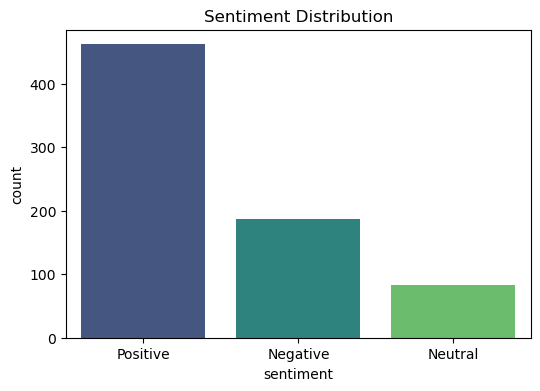

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["sentiment"], palette="viridis")
plt.title("Sentiment Distribution")
plt.show()


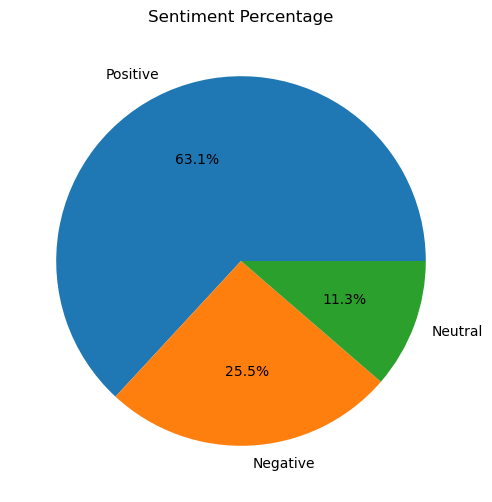

In [21]:
df["sentiment"].value_counts().plot(kind="pie", autopct="%1.1f%%", figsize=(6,6))
plt.title("Sentiment Percentage")
plt.ylabel("")
plt.show()

Word Cloud

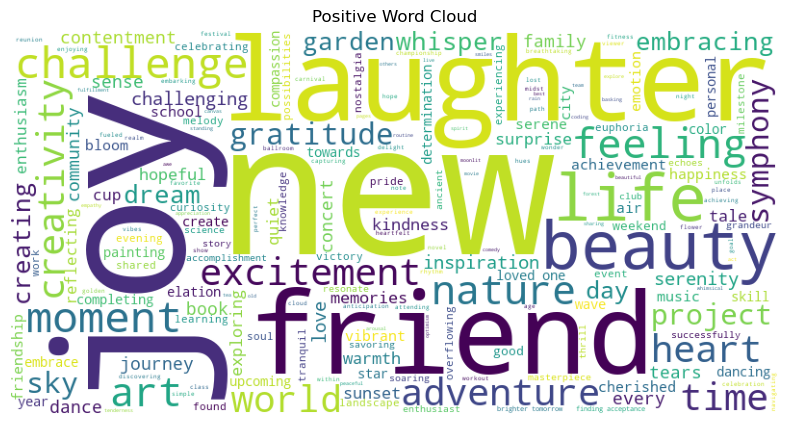

In [22]:
positive_text = " ".join(df[df.sentiment=="Positive"]["clean_text"])
wc = WordCloud(width=800, height=400, background_color="white").generate(positive_text)
plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")
plt.title("Positive Word Cloud")
plt.show()


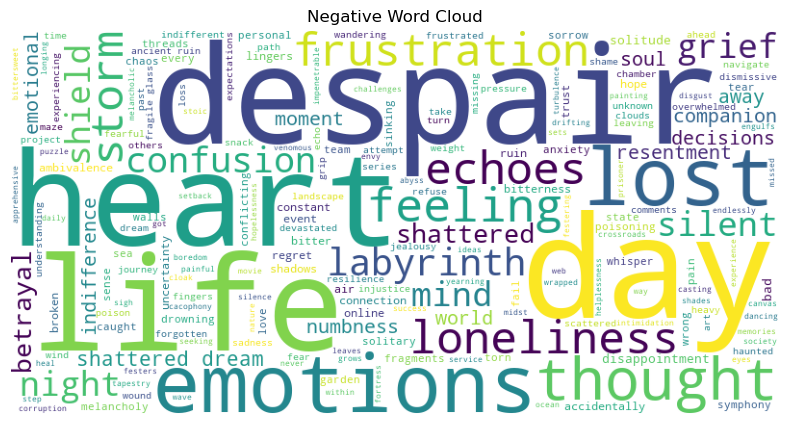

In [23]:
negative_text = " ".join(df[df.sentiment=="Negative"]["clean_text"])
wc = WordCloud(width=800, height=400, background_color="white").generate(negative_text)
plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")
plt.title("Negative Word Cloud")
plt.show()


Key Insights (Auto-generated)

In [27]:
print("Total Posts:", len(df))
print("\nSentiment Counts:\n", df["sentiment"].value_counts())

print("\nInsights:")
if df["sentiment"].value_counts().idxmax() == "Positive":
    print("✔ Majority of posts are Positive → Good brand perception.")
elif df["sentiment"].value_counts().idxmax() == "Negative":
    print("⚠ Many negative posts → Immediate marketing improvement needed.")
else:
    print("➖ Neutral sentiment dominates → Mixed perception.")

print("\nTop 5 Positive Posts:")
print(df[df.sentiment=="Positive"]["Text"].head())

print("\nTop 5 Negative Posts:")
print(df[df.sentiment=="Negative"]["Text"].head())


Total Posts: 732

Sentiment Counts:
 sentiment
Positive    462
Negative    187
Neutral      83
Name: count, dtype: int64

Insights:
✔ Majority of posts are Positive → Good brand perception.

Top 5 Positive Posts:
0      Enjoying a beautiful day at the park!        ...
2      Just finished an amazing workout! ðª       ...
3      Excited about the upcoming weekend getaway!  ...
5      Feeling grateful for the little things in lif...
11     Feeling a bit under the weather today.       ...
Name: Text, dtype: object

Top 5 Negative Posts:
1      Traffic was terrible this morning.           ...
6      Rainy days call for cozy blankets and hot coc...
9      Missing summer vibes and beach days.         ...
19     Winter blues got me feeling low.             ...
53     Feeling a sense of fear after watching a thri...
Name: Text, dtype: object
